# Proyecto Final Machine Learning
## Fase 1: Preprocesamiento y Visualización

**Dataset:** UCI HAR — Human Activity Recognition Using Smartphones  
**Equipo:** Grupo XX  
**Integrantes:** Jorge Rojas · Juan Madariaga  
**Fecha:** [Fecha de entrega]

---

> **Objetivo:** Comprender el dataset HAR, preparar los datos para el modelado y comunicar los hallazgos exploratorios mediante visualizaciones.

## Configuración del entorno

Ejecuta esta celda primero para instalar las dependencias necesarias.

In [2]:
# Instalación de dependencias (ejecutar solo si es necesario)
# !pip install pandas numpy matplotlib seaborn scikit-learn ucimlrepo --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

# Semilla global para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 1. Descarga y Carga del Dataset

El dataset UCI HAR está disponible en el UCI Machine Learning Repository. Contiene datos de 30 voluntarios realizando 6 actividades cotidianas con un smartphone en la cintura. Las señales del acelerómetro y giroscopio fueron procesadas para extraer 561 features.

In [3]:
import urllib.request
import zipfile
import os

# Descarga automática del dataset
URL = 'https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip'
ZIP_PATH = 'har_dataset.zip'
DATA_DIR = 'UCI HAR Dataset'

if not os.path.exists(DATA_DIR):
    print('Descargando dataset...')
    urllib.request.urlretrieve(URL, ZIP_PATH)
    print('Descomprimiendo...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('.')
    os.remove(ZIP_PATH)
    print('Dataset listo.')
else:
    print('Dataset ya descargado.')

Dataset ya descargado.


In [4]:
# TODO 1: Cargar los archivos del dataset
# Cargar: X_train.txt, y_train.txt, X_test.txt, y_test.txt, features.txt
# Usar rutas RELATIVAS (no absolutas)

DATA_PATH = 'UCI HAR Dataset'

# Cargar nombres de features
features = pd.read_csv(f'{DATA_PATH}/features.txt', sep=r'\s+', header=None, names=['idx', 'feature'])
feature_names = features['feature'].tolist()

# TODO: Cargar X_train y asignar feature_names como columnas
# Evitar error "Duplicate names are not allowed" haciendo únicos los nombres de feature
counts = {}
unique_feature_names = []
for n in feature_names:
    if n in counts:
        counts[n] += 1
        unique_feature_names.append(f"{n}_{counts[n]}")
    else:
        counts[n] = 0
        unique_feature_names.append(n)

feature_names = unique_feature_names
X_train = pd.read_csv(f'{DATA_PATH}/train/X_train.txt', sep=r'\s+', header=None, names=feature_names)

# TODO: Cargar y_train (sin header)
y_train = pd.read_csv(f'{DATA_PATH}/train/y_train.txt', sep=r'\s+', header=None, names=['label'])

# TODO: Cargar X_test y asignar feature_names como columnas
X_test = pd.read_csv(f'{DATA_PATH}/test/X_test.txt', sep=r'\s+', header=None, names=feature_names)

# TODO: Cargar y_test (sin header)
y_test = pd.read_csv(f'{DATA_PATH}/test/y_test.txt', sep=r'\s+', header=None, names=['label'])

In [5]:
# TODO 2: Mapear etiquetas numéricas a nombres de actividad
ACTIVITY_LABELS = {
    1: 'WALKING',
    2: 'WALKING_UPSTAIRS',
    3: 'WALKING_DOWNSTAIRS',
    4: 'SITTING',
    5: 'STANDING',
    6: 'LAYING'
}

# TODO: Aplicar el mapeo a y_train e y_test
y_train_labels = y_train['label'].map(ACTIVITY_LABELS)
y_test_labels  = y_test['label'].map(ACTIVITY_LABELS)

print('Clases únicas:', sorted(y_train_labels.unique()))

Clases únicas: ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']


---
## 2. Inspección Inicial del Dataset

Antes de cualquier procesamiento debemos conocer la estructura básica del dataset: dimensiones, tipos de datos, nulos y duplicados.

In [6]:
# TODO 3: Mostrar dimensiones de train y test
print('Dimensiones X_train:', X_train.shape)
print('Dimensiones X_test: ', X_test.shape)

Dimensiones X_train: (7352, 561)
Dimensiones X_test:  (2947, 561)


In [7]:
# TODO 4: Mostrar los primeros 5 registros y los tipos de datos
print('Primeros 5 registros de X_train:')
print(X_train.head())

print('Tipos de datos de X_train:')
print(X_train.dtypes.value_counts())

Primeros 5 registros de X_train:
   tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  \
0           0.288585          -0.020294          -0.132905         -0.995279   
1           0.278419          -0.016411          -0.123520         -0.998245   
2           0.279653          -0.019467          -0.113462         -0.995380   
3           0.279174          -0.026201          -0.123283         -0.996091   
4           0.276629          -0.016570          -0.115362         -0.998139   

   tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  tBodyAcc-mad()-Y  \
0         -0.983111         -0.913526         -0.995112         -0.983185   
1         -0.975300         -0.960322         -0.998807         -0.974914   
2         -0.967187         -0.978944         -0.996520         -0.963668   
3         -0.983403         -0.990675         -0.997099         -0.982750   
4         -0.980817         -0.990482         -0.998321         -0.979672   

   tBodyAcc-mad()-Z  tB

In [8]:
# TODO 5: Verificar valores faltantes (NaN)
missing_train = X_train.isnull().sum().sum()
missing_test  = X_test.isnull().sum().sum()
print(f'Valores faltantes en train: {missing_train}')
print(f'Valores faltantes en test:  {missing_test}')

Valores faltantes en train: 0
Valores faltantes en test:  0


In [9]:
# TODO 6: Verificar duplicados en el set de entrenamiento
duplicates = X_train.duplicated().sum()
print(f'Filas duplicadas en X_train: {duplicates}')

Filas duplicadas en X_train: 0


In [10]:
# TODO 7: Estadísticos descriptivos básicos
X_train.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754,-0.630512,-0.526907,-0.606150,-0.468604,...,0.125293,-0.307009,-0.625294,0.008684,0.002186,0.008726,-0.005981,-0.489547,0.058593,-0.056515
std,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687,0.424073,0.485942,0.414122,0.544547,...,0.250994,0.321011,0.307584,0.336787,0.448306,0.608303,0.477975,0.511807,0.297480,0.279122
min,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-0.995357,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233,-0.993591,-0.978162,-0.980251,-0.936219,...,-0.023692,-0.542602,-0.845573,-0.121527,-0.289549,-0.482273,-0.376341,-0.812065,-0.017885,-0.143414
50%,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365,-0.950709,-0.857328,-0.857143,-0.881637,...,0.134000,-0.343685,-0.711692,0.009509,0.008943,0.008735,-0.000368,-0.709417,0.182071,0.003181
75%,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415,-0.292680,-0.066701,-0.265671,-0.017129,...,0.289096,-0.126979,-0.503878,0.150865,0.292861,0.506187,0.359368,-0.509079,0.248353,0.107659
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.946700,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,1.000000,0.478157,1.000000


**Análisis:** *[Escriban aquí sus observaciones sobre el rango de valores. ¿Necesitan normalizar? ¿Por qué?]*

---
## 3. Análisis de Balance de Clases

El desbalance de clases puede sesgar el modelo. Antes de modelar, examinamos la distribución de actividades.

In [11]:
# TODO 8: Contar muestras por clase en el set de entrenamiento
class_counts = y_train_labels.value_counts()
print(class_counts)

label
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


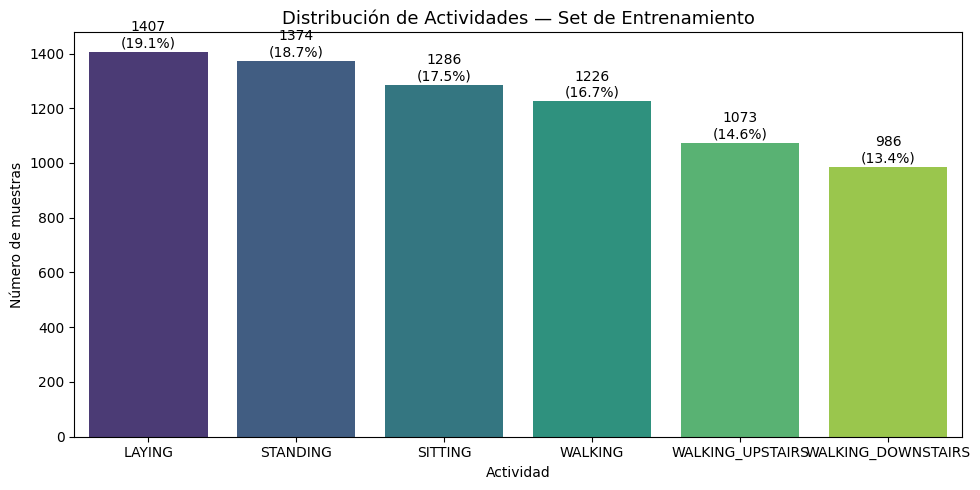

In [12]:
# TODO 9: Graficar distribución de clases con conteo y porcentaje
fig, ax = plt.subplots(figsize=(10, 5))

# TODO: Crear el barplot con etiquetas de conteo y porcentaje+
sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax, palette='viridis')
for i, count in enumerate(class_counts.values):
    percentage = count / len(y_train_labels) * 100
    ax.text(i, count + 5, f'{count}\n({percentage:.1f}%)', ha='center', va='bottom', fontsize=10)

ax.set_title('Distribución de Actividades — Set de Entrenamiento', fontsize=13)
ax.set_xlabel('Actividad')
ax.set_ylabel('Número de muestras')
plt.tight_layout()
plt.show()

**Análisis de balance:** *[¿Está balanceado el dataset? Justifica con los números. ¿Cómo podría afectar el desbalance al modelo? ¿Qué métrica sería más adecuada que la accuracy simple?]*

---
## 4. Visualización y Exploración de Features

Con 561 features no podemos visualizarlas todas. Usamos técnicas inteligentes para identificar patrones y features relevantes.

### 4.1 Distribución de features clave (Boxplots)

Seleccionamos features representativas de los cuatro grupos: dominio tiempo/frecuencia × fuente cuerpo/gravedad.

In [13]:
# Selección robusta de 4 features representativas
candidates = [
    'tBodyAcc-mean()-X',
    'tGravityAcc-mean()-X',
    'fBodyAcc-mean()-X',
    'fBodyGyro-mean()-X',
]

SELECTED_FEATURES = [c for c in candidates if c in X_train.columns]

# Si faltan, buscar columnas similares por patrón
if len(SELECTED_FEATURES) < 4:
    keys = ['tBodyAcc', 'tGravityAcc', 'fBodyAcc', 'fBodyGyro']
    for key in keys:
        if len(SELECTED_FEATURES) >= 4:
            break
        found = [col for col in X_train.columns if key in col and 'mean()' in col]
        for col in found:
            if col not in SELECTED_FEATURES:
                SELECTED_FEATURES.append(col)
            if len(SELECTED_FEATURES) >= 4:
                break

# Último recurso: top-4 por varianza
if len(SELECTED_FEATURES) < 4:
    SELECTED_FEATURES = X_train.var().nlargest(4).index.tolist()

# Crear DataFrame con features seleccionadas y etiqueta de actividad
train_plot = X_train[SELECTED_FEATURES].copy()
train_plot['Activity'] = y_train_labels.values

print('Selected features:', SELECTED_FEATURES)

Selected features: ['tBodyAcc-mean()-X', 'tGravityAcc-mean()-X', 'fBodyAcc-mean()-X', 'fBodyGyro-mean()-X']


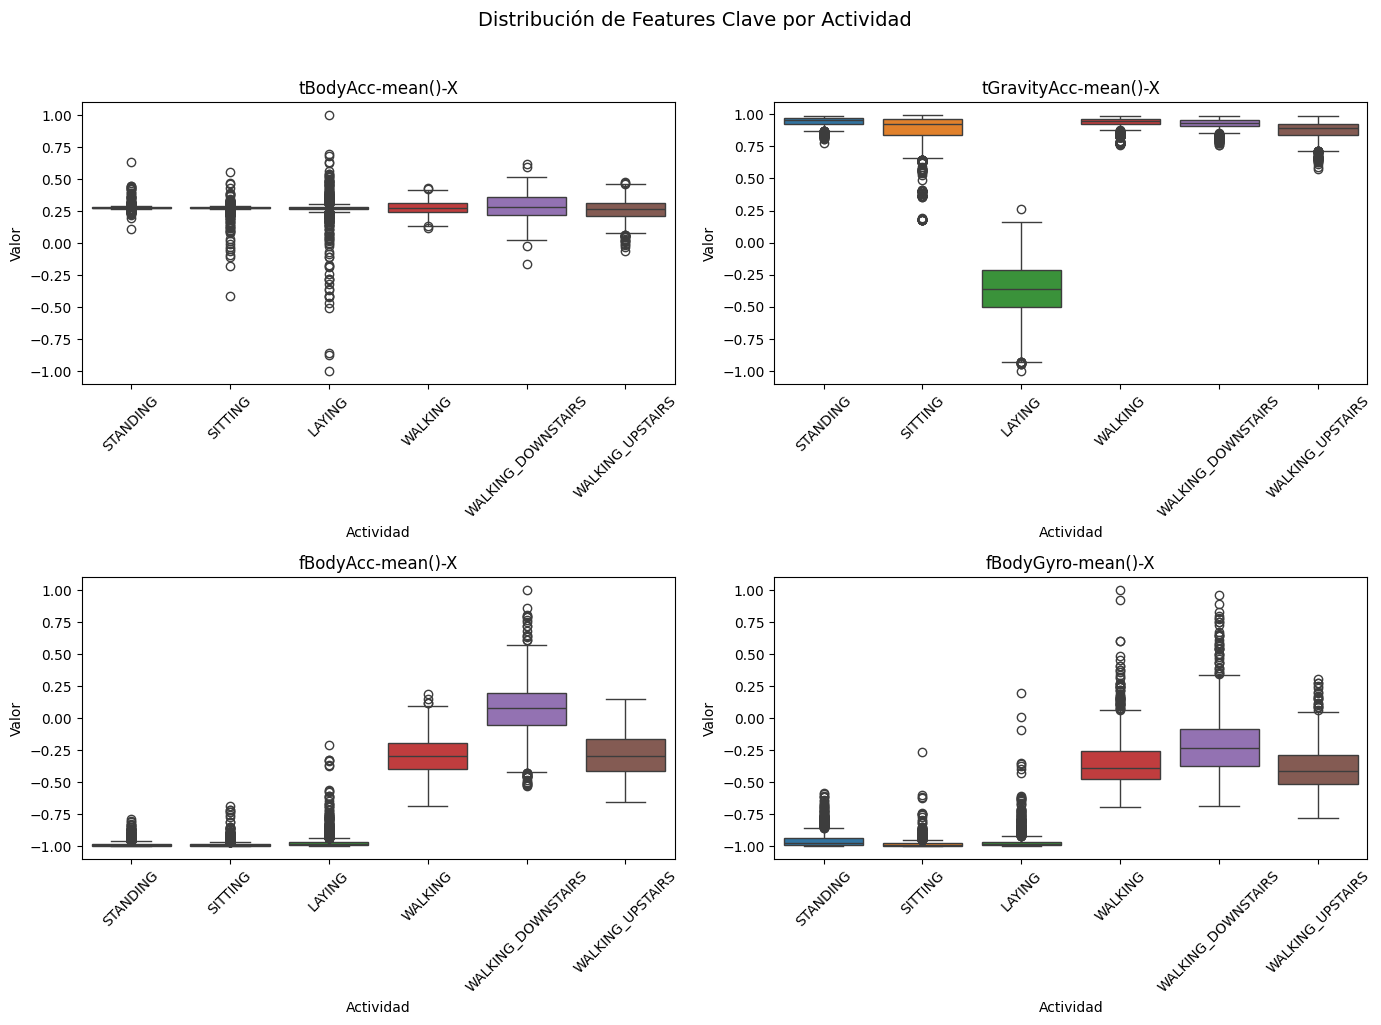

In [14]:
# Boxplots para las features seleccionadas (TODO 11)
if 'SELECTED_FEATURES' not in globals() or 'train_plot' not in globals():
    raise RuntimeError("Ejecuta la celda de selección de features (TODO 10) antes de esta.")

rows, cols = 2, 2
fig, axes = plt.subplots(rows, cols, figsize=(14, 10))
axes = axes.flatten()
palette = sns.color_palette('tab10')

# Plotear hasta rows*cols features
for i, feat in enumerate(SELECTED_FEATURES[: rows * cols]):
    ax = axes[i]
    if feat not in train_plot.columns:
        ax.text(0.5, 0.5, f'Feature no encontrada:\\n{feat}', ha='center', va='center')
        ax.set_title(feat)
        ax.set_xticks([])
        continue
    sns.boxplot(x='Activity', y=feat, data=train_plot, ax=ax, palette=palette)
    ax.set_title(feat)
    ax.set_xlabel('Actividad')
    ax.set_ylabel('Valor')
    ax.tick_params(axis='x', rotation=45)

# Ocultar subplots sobrantes
n = len(SELECTED_FEATURES)
for j in range(min(n, rows*cols), rows * cols):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Features Clave por Actividad', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Análisis:** *[¿Qué features separan mejor las clases? ¿Cuáles son menos informativas?]*

### 4.2 Mapa de calor de correlación

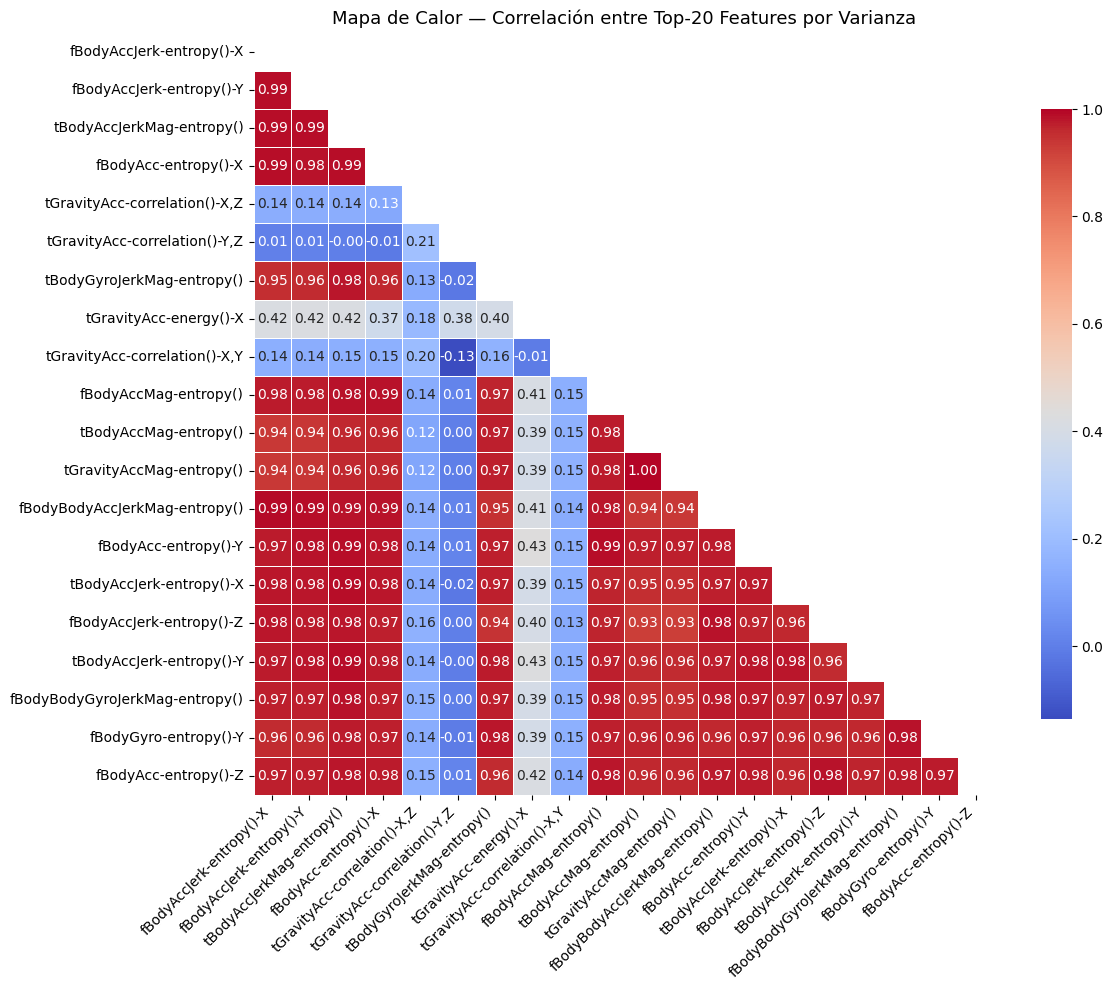

In [15]:
# Seleccionar las 20 features con mayor varianza
top_var_features = X_train.var().nlargest(20).index.tolist()

# Calcular y graficar el heatmap de correlación
corr_matrix = X_train[top_var_features].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    linewidths=.5,
    cbar_kws={'shrink': .8},
    ax=ax
)
ax.set_title('Mapa de Calor — Correlación entre Top-20 Features por Varianza', fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

**Análisis:** *[¿Qué implicaciones tiene la alta correlación entre features para algunos modelos? ¿Identifica grupos de features altamente correlacionadas?]*

### 4.3 Reducción de dimensionalidad — PCA

In [17]:
# TODO 14: Aplicar PCA para reducir a 2 dimensiones
from sklearn.preprocessing import StandardScaler

# Escalar antes de PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

pca = PCA(n_components=2, random_state=RANDOM_STATE)

# Ajustar y transformar X_train
X_pca = pca.fit_transform(X_train_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Activity'] = y_train_labels.values

print('Varianza explicada total:', pca.explained_variance_ratio_.sum())
print('Varianza explicada PC1:', pca.explained_variance_ratio_[0])
print('Varianza explicada PC2:', pca.explained_variance_ratio_[1])

Varianza explicada total: 0.5736185255809918
Varianza explicada PC1: 0.5078117229128636
Varianza explicada PC2: 0.06580680266812819


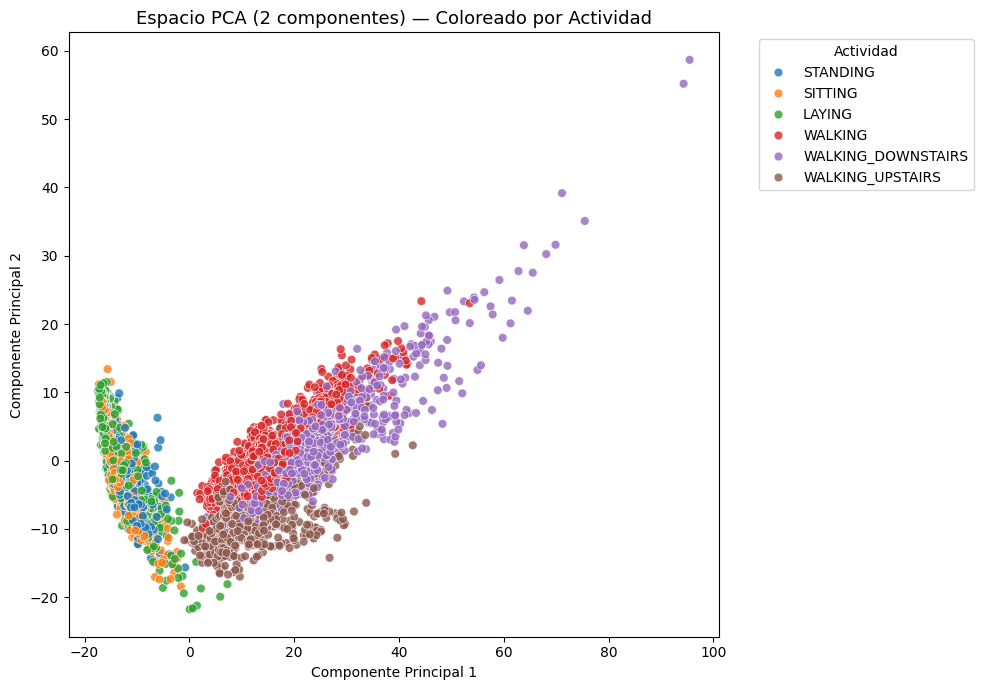

Varianza explicada PC1: 0.508
Varianza explicada PC2: 0.066


In [18]:
# TODO 15: Graficar espacio PCA coloreando por clase de actividad
fig, ax = plt.subplots(figsize=(10, 7))

palette = sns.color_palette('tab10', n_colors=df_pca['Activity'].nunique())
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Activity',
    palette=palette,
    data=df_pca,
    ax=ax,
    alpha=0.8,
    s=40
)

ax.set_title('Espacio PCA (2 componentes) — Coloreado por Actividad', fontsize=13)
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.legend(title='Actividad', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Varianza explicada
print(f'Varianza explicada PC1: {pca.explained_variance_ratio_[0]:.3f}')
print(f'Varianza explicada PC2: {pca.explained_variance_ratio_[1]:.3f}')

**Análisis PCA:** *[¿Las actividades están bien separadas en el espacio PCA? ¿Cuáles se solapan? ¿Qué sugiere esto sobre la separabilidad del problema?]*

### 4.4 Visualización adicional (libre)

Agregar al menos una visualización adicional a elección del grupo. Puede ser: histogramas de features, violin plots, t-SNE, distribución por sujeto, etc.

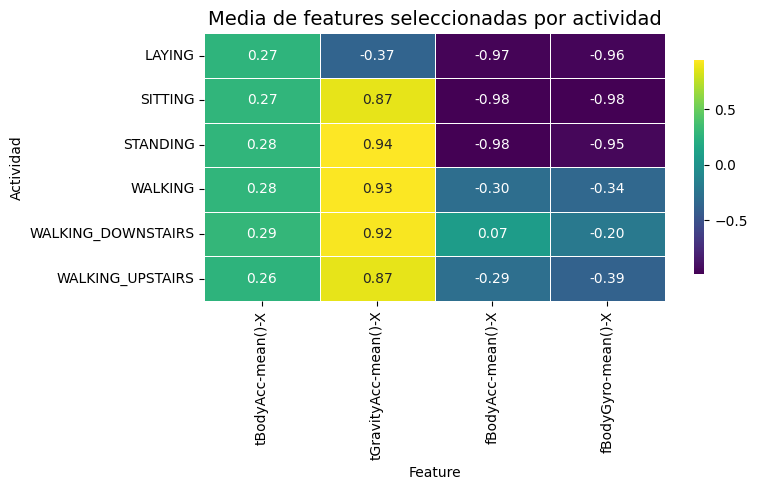

In [21]:
# Visualización adicional: heatmap de medias de features por actividad
if 'train_plot' not in globals() or 'SELECTED_FEATURES' not in globals():
    raise RuntimeError('Ejecuta primero la celda de selección de features (TODO 10).')

activity_means = train_plot.groupby('Activity')[SELECTED_FEATURES].mean()
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    activity_means,
    cmap='viridis',
    annot=True,
    fmt='.2f',
    linewidths=.5,
    cbar_kws={'shrink': .8},
    ax=ax
)
ax.set_title('Media de features seleccionadas por actividad', fontsize=14)
ax.set_xlabel('Feature')
ax.set_ylabel('Actividad')
plt.tight_layout()
plt.show()

**Análisis:** *[Describir e interpretar la visualización adicional.]*

---
## 5. Preparación Final de Datos

In [ ]:
# TODO 17: Confirmar que el split train/test viene predefinido (NO crear uno propio)
# El dataset ya provee los índices de sujetos para train/test
print('Sujetos únicos en train:', # TODO: identificar sujetos si están disponibles)
print('El split original es por sujeto, garantizando independencia entre sets.')

**¿Por qué es importante respetar el split original?** *[Explicar la importancia de no mezclar sujetos entre train y test para evitar data leakage.]*

In [ ]:
# TODO 18: Exportar variables limpias para la Fase 2
# (Simplemente confirmar que X_train, X_test, y_train, y_test están listos)

print('Variables disponibles para Fase 2:')
print(f'  X_train: {X_train.shape}')
print(f'  X_test:  {X_test.shape}')
print(f'  y_train: {y_train.shape}')
print(f'  y_test:  {y_test.shape}')

---
## 6. Resumen Final de la Fase 1

In [ ]:
# Celda de resumen — ejecutar al final para verificar todo
print('=' * 50)
print('RESUMEN FASE 1')
print('=' * 50)
print(f'Dimensiones X_train:   {X_train.shape}')
print(f'Dimensiones X_test:    {X_test.shape}')
print(f'Número de clases:      {len(ACTIVITY_LABELS)}')
print(f'Nombres de clases:     {list(ACTIVITY_LABELS.values())}')
print(f'Valores faltantes:     {X_train.isnull().sum().sum() + X_test.isnull().sum().sum()}')
print(f'Duplicados en train:   {X_train.duplicated().sum()}')
print('=' * 50)

RESUMEN FASE 1
Dimensiones X_train:   (7352, 561)
Dimensiones X_test:    (2947, 561)
Número de clases:      6
Nombres de clases:     ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']
Valores faltantes:     0
Duplicados en train:   0
